# Preamble

In [ ]:
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')

path = './data/'
tags = [
    'Periodic/PBED3/SEED1/DSET1',
    'Periodic/PBED2/SEED1/DSET1',
    'Periodic/B97D3/SEED1/DSET1',
]

scale = 2.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

In [402]:
label_map = {
    'PBED3':'PBE-D3',
    'PBED2':'PBE-D2',
    'B97D3':'B97-D3',
}

comp_map = {
    '000conEC':'EMC',
    '033conEC':'EC:EMC (3:7)',
    '066conEC':'EC:EMC (7:3)',
    '100conEC':'EC',
}

traj_map = {
    'npt_000conEC_298K':'EMC',
    'npt_033conEC_298K':'EC:EMC (3:7)',
    'npt_066conEC_298K':'EC:EMC (7:3)',
    'npt_100conEC_313K':'EC',
}

model_map = {
    'Periodic_PBED3':'PBE-D3',
    'Periodic_PBED2':'PBE-D2',
    'Periodic_B97D3':'B97-D3',
}

In [447]:
def get_dynamic_data(data, handle=''):
    """Collect time (fs) and MSD (Å/fs) vectors.
    
    This function can be modified to treat any data based on the handle-variable.
    """
    if handle in ('B97D3', 'PBED3', 'PBED2', 'SD22N', 'SD22NQ', 'SD22NQQ'):
        time = data['Time']['data']
        msd = data['MSD']['data']
        density = data['Density']['data']
    return time, msd, density


def get_trajectory_results(thermo, threshold=5e-2, window=2000):
    results = {
        'Data set':[],
        'Labels':[],
        'Seed ID':[],
        'Sample ID':[],
        'Composition':[],
        'Temperature /K':[],
        'Density /g*cm-3':[],
        'Density std. /g*cm-3':[],
        'Diff. coeff. /1e6 cm2*s-1':[],
        'Diff. fit slope error /1e6 cm2*s-1':[],
        'Diff. fit R2':[],
        'Start time /ns':[],
        'Start time R2':[],
    }
    print(f'Using slope error thresold of: {threshold}, and moving window of: {window} frames')
    for i, tag in enumerate(thermo):
        print()
        print(tag)
        data_set, labels, seed, dset_sample = tag.split('/')
        seed_id = int(seed[-1])
        sample_id = int(dset_sample[-1])
        for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
            print(traj_name)
            ensemble, comp, temp = traj_name.split('_')
            temp = int(temp[:-1])
            
            # Collect data
            ## If loading data from sources with a different structure from this, this must be controlled using
            ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
            time, msd, density = get_dynamic_data(traj_data, handle=labels)

            # Obtain optimal starting time from unit log-log slope by fitting slopes in a moving window
            start_index, start_time_R2 = get_start_index(time, msd, threshold=threshold, window=window, start_id=0)

            if start_index != None:
                # Obtain diffusion coefficient with fitting errors
                diffusion_coeff, slope_error, diffusion_coeff_R2 = diffusion_coefficient(time[start_index:],msd[start_index:])
                print(f'start index: {start_index}, time steps: {len(time)}, start time R2: {start_time_R2:.5f}, Diff. coeff. (m^2/s): {diffusion_coeff:.5e}, slope error: {slope_error:.5e}, Diff. coeff. R2: {diffusion_coeff_R2:.5f}')
                
                results['Data set'].append(data_set)
                results['Labels'].append(label_map[labels])
                results['Seed ID'].append(seed_id)
                results['Sample ID'].append(sample_id)
                results['Composition'].append(comp_map[comp])
                results['Temperature /K'].append(temp)
                results['Density /g*cm-3'].append(np.mean(density))
                results['Density std. /g*cm-3'].append(np.std(density))
                results['Diff. coeff. /1e6 cm2*s-1'].append(diffusion_coeff*1e10)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(slope_error*1e10)
                results['Diff. fit R2'].append(diffusion_coeff_R2)
                results['Start time /ns'].append(time[start_index]*1e-6)
                results['Start time R2'].append(start_time_R2)
            else:
                results['Data set'].append(np.nan)
                results['Labels'].append(np.nan)
                results['Seed ID'].append(np.nan)
                results['Sample ID'].append(np.nan)
                results['Composition'].append(np.nan)
                results['Temperature /K'].append(np.nan)
                results['Density /g*cm-3'].append(np.nan)
                results['Density std. /g*cm-3'].append(np.nan)
                results['Diff. coeff. /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit slope error /1e6 cm2*s-1'].append(np.nan)
                results['Diff. fit R2'].append(np.nan)
                results['Start time /ns'].append(np.nan)
                results['Start time R2'].append(np.nan)
    df = pd.DataFrame(results)
    return df


def get_xyz(tag, handle='xyz'):
    import glob
    flist = [name for name in glob.glob(tag)]
    for f in flist:
        if handle in f:
            print(f)
            return read(f, ':')


def RMSE(x,y):
    rmse = np.sqrt(np.mean((x-y)**2))
    rrmse = rmse/np.sqrt(np.mean((x-np.mean(x))**2))
    return rmse, rrmse


def get_all_thermo(tag, handle='.thermo'):
    """This needs to be exhanged for Ioans version in order to be consistent with
    zenodo.
    """
    import glob
    import os
    from aseMolec import pltProps as pp
    
    thermo = {}
    flist = [name for name in glob.glob(tag) if handle in name]
    for f in flist:
        print(f)
        aux = os.path.basename(f)
        key = os.path.splitext(aux)[0]
        if 'xyz' in handle:
            thermo.update({key: read(f, ':')})
        else:
            thermo.update({key: pp.loadtxttag(f)})
    return thermo


def diffusion_coefficient(time, msd):
    """Determines the diffusion coefficient in three dimensions
    from the slope of the MSD-curve.
    """
    from scipy.stats import linregress

    res = linregress(time,msd)
    diffusion_coeff = res.slope/6 #final unit: A^2/fs
    diffusion_coeff *= 1e-5 #final unit: m^2/s
    diffusion_err = res.stderr*1e-5 #final unit: m^2/s

    # Two-sided t-test for error in slope
    from scipy.stats import t
    tinv = lambda p, df: abs(t.ppf(p/2, df))
    ts = tinv(0.05, len(time)-2)
    return diffusion_coeff, ts*diffusion_err, res.rvalue**2


def get_slope(time, msd):
    from scipy.stats import linregress
    res = linregress(time,msd)
    return res.slope, res.intercept, res.stderr, res.rvalue**2


def get_start_index(time, msd, threshold, window, start_id=0):
    window = int(window)
    start_id = int(start_id)
    ids = {}
    for i, t in enumerate(time[start_id:]):
        if i > window:
            
            slope, intercept, err, r2 = get_slope(np.log(time[i:i+window]),np.log(msd[i:i+window]))
            if abs(slope-1) < threshold:
                ids[start_id+i] = r2
    idx, r2 = max(ids.items(), key=lambda x: x[1])
    return idx, r2


def rvalue_formatting(x):
    if x < 0.8:
        return 'background-color: red'
    elif x < 0.9:
        return 'background-color: orange'
    elif x < 0.95:
        return 'background-color: yellow'
    else:
        return None


def get_colour(name):
    colmap = {
        'EMC':'blue',
        'EC:EMC (3:7)':'green',
        'EC:EMC (7:3)':'yellow',
        'EC':'red',
    }
    return getattr(cset, colmap[name])


def get_mol_positions(atoms):
	positions = []
	mol_set = set(atoms.arrays['molID'])
	for ID in mol_set:
		mol = atoms[atoms.arrays['molID'] == ID]
		com = mol.get_center_of_mass()
		positions.append(com)
	positions = np.array(positions)
	return positions#, len(mol_set)


def mol_rdf(atoms, rmax, nbins, return_num_mols=False):
	positions = get_mol_positions(atoms)
	nmols, dim = positions.shape
	box_length = atoms.get_volume()**(1/3)
	for i, p in enumerate(positions):
		# PBC
		delta = positions[i+1:]-positions[i]
		delta -= box_length*np.round(delta/box_length)
		
		# Get counts
		dists = np.linalg.norm(delta, axis=1)
		s = sorted(dists[dists <= rmax])[1:]
		if i == 0:
			counts, bins = np.histogram(s, nbins, (0,rmax))
		else:
			counts += np.histogram(s, nbins, (0,rmax))[0]

	if return_num_mols:
		return counts, bins, nmols
	else:
		return counts, bins
     

def compute_rdf(traj, rmax=None, nbins=100, return_rho=False):
	for i, atoms in enumerate(traj):
		if i == 0:
			counts, bins, nmols = mol_rdf(atoms, rmax=rmax, nbins=nbins, return_num_mols=True)
			volume = atoms.get_volume()
			box_length = volume**(1/3)
			r = 0.5*(bins[1:]+bins[:-1])
		else:
			counts += mol_rdf(atoms, rmax=rmax, nbins=nbins)[0]
	
	num_snapshots = i+1
	nvalid = nmols/2
	n_k = counts/(nvalid*num_snapshots)	
	dr = rmax/nbins
	shell_volumes = 4/3*np.pi*((r+dr)**3-r**3)
	rho = nmols/volume
	
	g = n_k/(rho*shell_volumes)
	if return_rho:
		return g, r, rho
	else:
		return g, r


def get_rdfs(path, tags, slice=':'):
    import glob
    from aseMolec import anaAtoms as aa

    rdfs = {}
    number_densities = {}
    for tag in tags:
        data_set, labels, seed, dset_sample = tag.split('/')
        flist = [name for name in glob.glob(f'{path}{tag}/dynamics/*') if '.xyz' in name]
        name = f'{data_set}_{labels}'
        print(name, dset_sample, seed)

        for file in flist:
            print(file)
            comp = file.split('/')[-1].split('.')[0][4:-5]
            comp = comp_map[comp]
            traj = read(file, slice)
            aa.find_molecs(traj, fct=1.0)
            g, r, rho = compute_rdf(traj, rmax=11, return_rho=True)

            if name not in rdfs:
                rdfs[name] = {}
            if dset_sample not in rdfs[name]:
                rdfs[name][dset_sample] = {}
            if seed not in rdfs[name][dset_sample]:
                rdfs[name][dset_sample][seed] = {}
            
            if name not in number_densities:
                number_densities[name] = {}
            if dset_sample not in number_densities[name]:
                number_densities[name][dset_sample] = {}
            if seed not in number_densities[name][dset_sample]:
                number_densities[name][dset_sample][seed] = {}

            rdfs[name][dset_sample][seed][comp] = [g, r]
            number_densities[name][dset_sample][seed][comp] = rho
            del traj
    
    return rdfs, number_densities

def get_indices_of_sign_change(lst):
    arr = np.array(lst)
    sign_changes = np.where(np.diff(np.sign(arr)) != 0)[0]
    return sign_changes


def yaml_to_multidf(fname, index_list):
    import yaml
    import pandas as pd
    # Load YAML
    with open(fname, "r") as f:
        raw = yaml.safe_load(f)
    f.close()

    # Convert to DataFrame
    df = pd.DataFrame(raw['metadata'])

    # Set MultiIndex
    df = df.set_index(index_list)
    return df


def download_file(url, output_file):
	import requests
	from pathlib import Path
	print(f"Downloading {url} -> {output_file}")
	response = requests.get(url)
	response.raise_for_status()

	Path(output_file).parent.mkdir(parents=True, exist_ok=True)

	with open(output_file, "wb") as f:
		f.write(response.content)


def unzip_file(zip_path, extract_to):
	from pathlib import Path
	import zipfile
	print(zip_path)
	print(f"Unzipping {zip_path} -> {extract_to}")
	Path(extract_to).mkdir(parents=True, exist_ok=True)

	with zipfile.ZipFile(zip_path, "r") as z:
		z.extractall(extract_to)


def download_unpack(root, config_path, key):
	import yaml
	with open(root+config_path, "r") as f:
		config = yaml.safe_load(f)

	for item in config[key]:
		url = item["url"]
		output_file = item["output_file"]
		extract_to = item["extract_to"]

		download_file(url, root+output_file)
		unzip_file(root+output_file, root+extract_to)


___
# Download MLIP data

In [ ]:
download_file("https://zenodo.org/api/records/10712131/draft/files/periodic_metadata.yaml/content?access_token=NwtW1nUYxaPUKiRAaoDsFPNwmrweTDvms4GXDPWJpmOdA7q6NB1LPqSUVNiw" , path+"periodic_metadata.yaml")
download_unpack(path, "periodic_metadata.yaml", "MLIP downloads")

# Data overview

In [444]:
meta_df = yaml_to_multidf(path+"periodic_metadata.yaml", ["Data set", "Labels"])
meta_df

Subset  Seeds  Number of structures  Number of atoms
Data set Labels                                                      
Periodic PBE-D2       1      1                   935            66188
         PBE-D3       1      1                   935            66188
         B97-D3       1      1                   935            66188

# Results

## Training errors

In [445]:
# Obtain data and store to dicts
xyz = dict()
for tag in tags:
    xyz[tag] = get_xyz(f'{path}{tag}/training/evaluation/*') # Argument should be 'tag' to be consistent with zenodo

../publication/dltest/Periodic/PBED3/SEED1/DSET1/training/evaluation/IBM23_PBED3.xyz
../publication/dltest/Periodic/PBED2/SEED1/DSET1/training/evaluation/IBM23_PBED2.xyz
../publication/dltest/Periodic/B97D3/SEED1/DSET1/training/evaluation/IBM23_B97D3BJ_Vasp.xyz


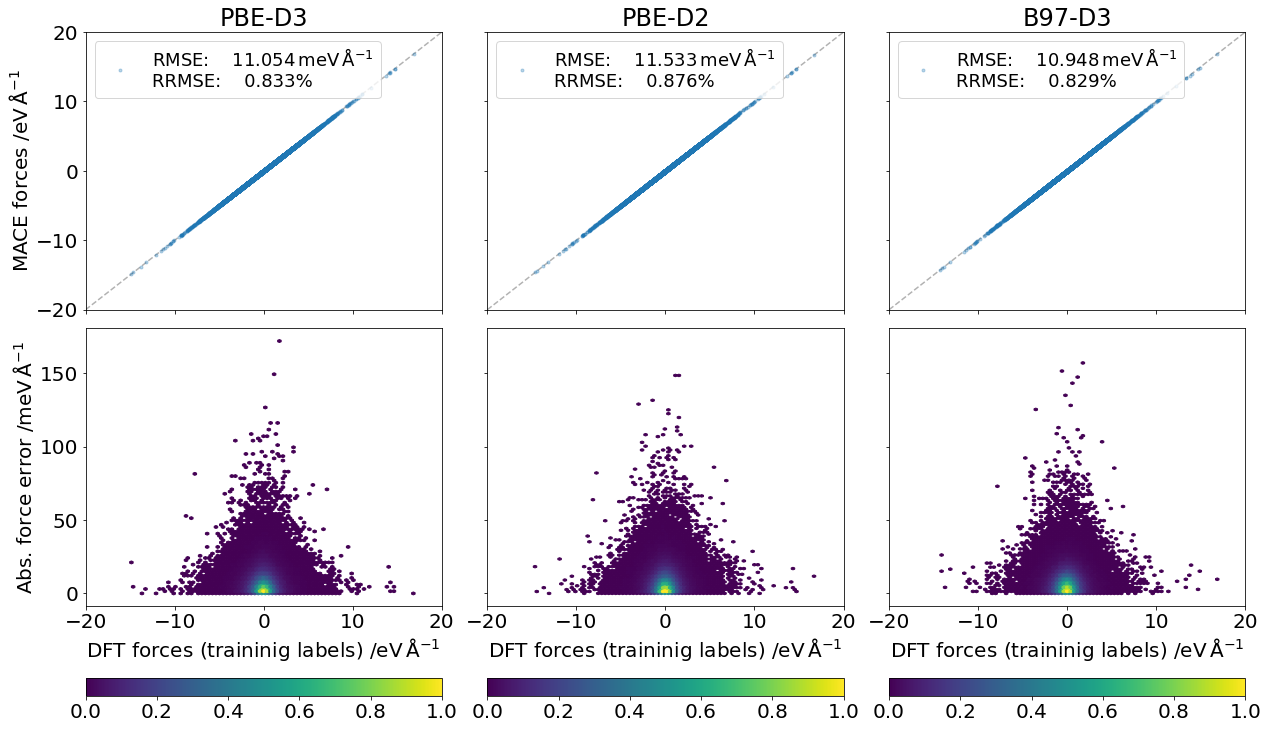

In [446]:
fig, axs = plt.subplots(2,len(tags), figsize=(7*scale, 4*scale), sharex=True, sharey='row', layout='constrained')
for i, k in enumerate(xyz):
    tag = tags[i]
    atoms = xyz[k]
    data_set, labels, seed, dset_sample = tag.split('/')
    
    # Obtain forces and errors
    ## reference
    ref_forces = [a.arrays['forces'] for a in atoms if 'forces' in a.arrays.keys()]
    ref_forces = np.concatenate(ref_forces).flatten()

    ## mace
    mace_forces = [a.arrays['MACE_forces'] for a in atoms if 'forces' in a.arrays.keys()]
    mace_forces = np.concatenate(mace_forces).flatten()
    rmse, rrmse = RMSE(ref_forces, mace_forces)

    # Plot correlations
    axs[0,i].set_title(label_map[labels])
    axs[0,i].plot(ref_forces, mace_forces, '.', label=f'RMSE:    {rmse*1e3:.3f}$\\,$meV$\,$Å$^{{-1}}$\nRRMSE:    {rrmse*100:.3f}%', alpha=0.3, rasterized=True)
    axs[0,i].legend(loc='upper left', numpoints=1, fontsize=fsize-2)

    # Plot settings
    axs[0,i].plot([0, 1], [0, 1], 'k--', transform=axs[0,i].transAxes, alpha=0.3, zorder=0)
    axs[0,i].set_xlim([-20,20])
    axs[0,i].set_ylim([-20,20])
    if i == 0: axs[0,i].set_ylabel('MACE forces /eV$\,$Å$^{-1}$')

    h = axs[1,i].hexbin(
        ref_forces,
        abs(ref_forces-mace_forces)*1000,
        mincnt=1,
    )
    counts = h.get_array()
    counts_min = counts.min()
    counts_max = counts.max()
    counts_scaled = (counts - counts_min) / (counts_max - counts_min)
    h.set_array(counts_scaled)
    h.set_norm(mcolors.Normalize(vmin=0, vmax=1))
    
    plt.colorbar(h, ax=axs[1,i], orientation='horizontal')
    axs[1,i].set_xlabel('DFT forces (traininig labels) /eV$\,$Å$^{-1}$')
    axs[1,0].set_ylabel('Abs. force error /meV$\,$Å$^{-1}$')

## Download MD simulation data

In [ ]:
download_unpack(path, "periodic_metadata.yaml", "MDSims downloads")

## NPT Dynamics

In [416]:
thermo = dict()
for tag in tags:
    thermo[tag] = get_all_thermo(f'{path}{tag}/dynamics/*', handle='.thermo') # Argument should be 'tag' to be consistent with zenodo

../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo


Calculate diffusion coefficients and collect data

In [421]:
df = get_trajectory_results(thermo)
pd.to_pickle(df, './part1_results.pkl')

Using slope error thresold of: 0.05, and moving window of: 2000 frames

Periodic/PBED3/SEED1/DSET1
npt_000conEC_298K
start index: 2458, time steps: 99999, start time R2: 0.96474, Diff. coeff. (m^2/s): 1.63256e-09, slope error: 5.97726e-12, Diff. coeff. R2: 0.99063
npt_033conEC_298K
start index: 2999, time steps: 99999, start time R2: 0.97851, Diff. coeff. (m^2/s): 1.11270e-09, slope error: 3.18820e-12, Diff. coeff. R2: 0.99427
npt_066conEC_298K
start index: 2201, time steps: 99999, start time R2: 0.94846, Diff. coeff. (m^2/s): 9.39180e-10, slope error: 2.82727e-12, Diff. coeff. R2: 0.99363
npt_100conEC_313K
start index: 5781, time steps: 99998, start time R2: 0.96311, Diff. coeff. (m^2/s): 7.02386e-10, slope error: 3.14588e-12, Diff. coeff. R2: 0.98652

Periodic/PBED2/SEED1/DSET1
npt_000conEC_298K
start index: 2136, time steps: 99997, start time R2: 0.97257, Diff. coeff. (m^2/s): 1.34273e-09, slope error: 5.89679e-12, Diff. coeff. R2: 0.98654
npt_033conEC_298K
start index: 4329, time s

Data summary:

In [422]:
df = pd.read_pickle('./part1_results.pkl')
df.style.map(rvalue_formatting, subset=['Start time R2', 'Diff. fit R2'])

,Data set,Labels,Seed ID,Sample ID,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1,Diff. fit R2,Start time /ns,Start time R2
0,Periodic,PBE-D3,1,1,EMC,298,0.965048,0.016399,16.325551,0.059773,0.990634,0.024580,0.964739
1,Periodic,PBE-D3,1,1,EC:EMC (3:7),298,1.040782,0.016999,11.127035,0.031882,0.994275,0.029990,0.978507
2,Periodic,PBE-D3,1,1,EC:EMC (7:3),298,1.129481,0.015671,9.391799,0.028273,0.993632,0.022010,0.948457
3,Periodic,PBE-D3,1,1,EC,313,1.232997,0.016728,7.023863,0.031459,0.986518,0.057810,0.963111
4,Periodic,PBE-D2,1,1,EMC,298,1.047056,0.016843,13.427267,0.058968,0.986536,0.021360,0.972574
5,Periodic,PBE-D2,1,1,EC:EMC (3:7),298,1.129350,0.015385,7.664463,0.024575,0.992939,0.043290,0.918681
6,Periodic,PBE-D2,1,1,EC:EMC (7:3),298,1.225467,0.015899,5.999196,0.028784,0.983952,0.020140,0.939310
7,Periodic,PBE-D2,1,1,EC,313,1.337139,0.015780,4.889075,0.014162,0.994175,0.034270,0.954229
8,Periodic,B97-D3,1,1,EMC,298,1.089476,0.016971,5.707808,0.016959,0.993916,0.041060,0.976816
9,Periodic,B97-D3,1,1,EC:EMC (3:7),298,1.149753,0.015724,4.435677,0.016567,0.990403,0.039230,0.918939


Visual summary:

/tmp/ipykernel_523725/999747581.py:61: UserWarning:

Attempt to set non-positive ylim on a log-scaled axis will be ignored.



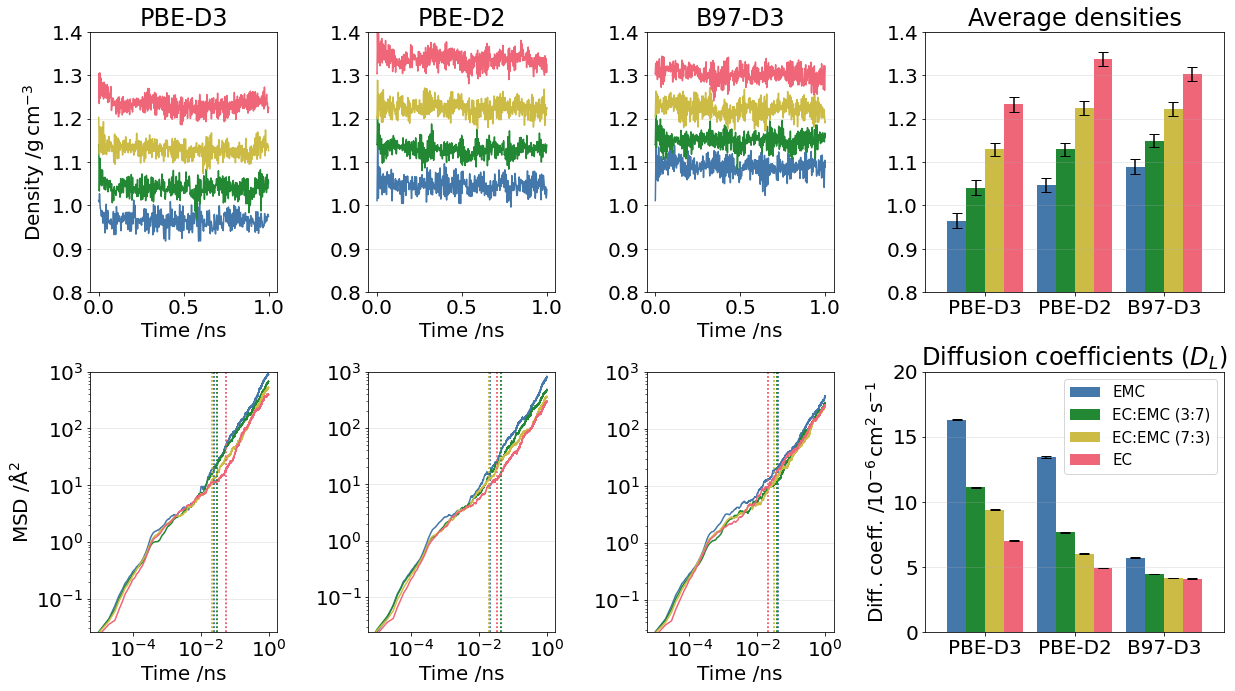

In [423]:
fig, axs = plt.subplots(2,len(tags)+1, figsize=(7*scale, 4*scale), gridspec_kw={'width_ratios': [1, 1, 1, 1.6]})

order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
group_order = [
    'PBE-D3',
    'PBE-D2',
    'B97-D3',
]


# Pivot tables for plotting
plot_df = df.copy().drop('Seed ID', axis=1)
plot_df = plot_df.drop('Sample ID', axis=1)
avg_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Density /g*cm-3',
).reindex(group_order)[order]

std_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Density std. /g*cm-3',
).reindex(group_order)[order]

diff_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Diff. coeff. /1e6 cm2*s-1',
).reindex(group_order)[order]

differr_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Diff. fit slope error /1e6 cm2*s-1',
).reindex(group_order)[order]


# Plot trajectories
for i, tag in enumerate(thermo):
    data_set, labels, seed, dset_sample = tag.split('/')
    for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
        name = traj_map[traj_name]

        # Collect data
        ## If loading data from sources with a different structure from this, this must be controlled using
        ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
        time, msd, dens = get_dynamic_data(traj_data, handle=labels)

        # Plot density
        axs[0,i].set_ylim([0.8, 1.4])
        if i == 0: axs[0,i].set_ylabel(f'Density /g$\\,$cm$^{{-3}}$')
        axs[0,i].plot(time/1e6,dens, label=name, color=get_colour(name))

        # Plot MSD
        axs[1,i].set_ylim([0, 1000])
        if i == 0: axs[1,i].set_ylabel(f'MSD /Å$^2$')
        axs[1,i].plot(time/1e6,msd, label=name, color=get_colour(name))
        axs[1,i].set_xscale('log')
        axs[1,i].set_yscale('log')

        # Plot vertical start times
        axs[1,0].axvline(plot_df['Start time /ns'].iloc[j], 0, 1, color=get_colour(name), alpha=1, linestyle='dotted')
        axs[1,1].axvline(plot_df['Start time /ns'].iloc[j+4], 0, 1, color=get_colour(name), alpha=1, linestyle='dotted')
        axs[1,2].axvline(plot_df['Start time /ns'].iloc[j+8], 0, 1, color=get_colour(name), alpha=1, linestyle='dotted')
      
        # Plot settings
        axs[0,i].set_title(label_map[labels])
        axs[0,i].set_xlabel(f'Time /ns')
        axs[1,i].set_xlabel(f'Time /ns')
        axs[0,i].grid(axis='y', alpha=0.3)
        axs[1,i].grid(axis='y', alpha=0.3)


# Plot averages
## Density
axs[0,-1].set_title('Average densities')
a0 = avg_pivot_df.plot.bar(
    ylim=[0.8,1.4],
    xlabel='',
	yerr=std_pivot_df,
    capsize=5,
    rot=0,
    width=0.85,
    color=[get_colour(o) for o in order],
    ax=axs[0,-1],
    legend=False,
)
axs[0,-1].grid(axis='y', alpha=0.3)

## Diff. coeff.
axs[1,-1].set_title('Diffusion coefficients ($D_L$)')
a1 = diff_pivot_df.plot.bar(
    ylim=[0,20],
    xlabel='',
    ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
	yerr=differr_pivot_df,
    capsize=5,
    rot=0,
    width=0.85,
    color=[get_colour(o) for o in order],
    ax=axs[1,-1],
    legend=False,
)
axs[1,-1].grid(axis='y', alpha=0.3)
axs[1,-1].legend(loc='upper right', fontsize=fsize-5)

plt.tight_layout()

## Finite size correction of diffusion coefficients
For the diffusion data, we first need to compute the correction coefficients used by [Schrodinger SI, equ 5](https://pubs.acs.org/doi/suppl/10.1021/acs.jpcb.2c03746/suppl_file/jp2c03746_si_001.pdf) and [Bamboo, equ 61](https://arxiv.org/pdf/2404.07181), quoting [standard practice, equ 3](https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e6324/937).
$$
D(\infty)=D(L)+\frac{2.837298\times k_BT}{6\pi \eta L}
$$
Box sizes are computed from number of molecules (table S1) and densities (table S2) from Schrodinger, temperatures are taken from table S1 and viscosity from table S3.

In [167]:
mass_thermo = get_all_thermo(f'{path}{tags[-1]}/dynamics/*', handle='.xyz') # Argument should be 'tag' to be consistent with zenodo

for comp, traj in mass_thermo.items():
    if '000conEC' in comp:
        print('Pure EMC:')
        M_EMC = traj[0].get_masses().sum() # u=g/mol
        m_EMC = M_EMC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EMC} kg')
    elif '100conEC' in comp:
        print('Pure EC:')
        M_EC = traj[0].get_masses().sum() # u=g/mol
        m_EC = M_EC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EC} kg')

../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz
Pure EMC:
Total mass:	1.1582317925845882e-23 kg
Pure EC:
Total mass:	1.462303889780969e-23 kg


In [425]:
m_EC = 1.462303889780969e-23
eta_EC = 1.93e-3 # Pa s
m_EMC = 1.1582317925845882e-23
eta_EMC = 0.65e-3 # Pa s*
kB = ase.units.kB/ase.units.J
xi = 2.837298
print(f'EMC viscosity:\t{eta_EMC} Pa s (at 298 K)')
print(f'EC viscosity:\t{eta_EC} Pa s (at 313 K)')
print(f'kB:\t\t{kB} J\n')

corr_df = plot_df.copy()
corr_df = corr_df[(corr_df['Composition'] == 'EMC') | (corr_df['Composition'] == 'EC')]
for tag, data in thermo.items():
    print(tag)
    data_set, labels, seed, dset = tag.split('/')
    for comp, traj in data.items():
        temp = int(comp.split('_')[-1][:-1])
        time, msd, dens = get_dynamic_data(traj_data, handle=labels)
        dens = np.mean(dens)*1000 # kg/m3

        if '000conEC' in comp:
            print('EMC:')
            total_mass = m_EMC
            eta = eta_EMC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        elif '100conEC' in comp:
            print('EC:')
            total_mass = m_EC
            eta = eta_EC
            volume = total_mass/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        else:
            corr = 0
        
        corr *= 1e10 # 1e-6 cm2/s
        if corr > 0:
            print(f'Box length:\t{L*1e10:.3f} Å')
            print(f'Correction:\t{corr:.3f} 1e-6cm2/s\n')

        func_mask = corr_df['Labels'] == labels
        comp_mask = corr_df['Composition'] == traj_map[comp]        
        corr_df.loc[func_mask & comp_mask, 'Diff. coeff. /1e6 cm2*s-1'] += corr
corr_df

EMC viscosity:	0.00065 Pa s (at 298 K)
EC viscosity:	0.00193 Pa s (at 313 K)
kB:		1.38064852e-23 J

Periodic/PBED3/SEED1/DSET1
EMC:
Box length:	20.717 Å
Correction:	4.599 1e-6cm2/s

EC:
Box length:	22.391 Å
Correction:	1.505 1e-6cm2/s

Periodic/PBED2/SEED1/DSET1
EMC:
Box length:	20.717 Å
Correction:	4.599 1e-6cm2/s

EC:
Box length:	22.391 Å
Correction:	1.505 1e-6cm2/s

Periodic/B97D3/SEED1/DSET1
EMC:
Box length:	20.717 Å
Correction:	4.599 1e-6cm2/s

EC:
Box length:	22.391 Å
Correction:	1.505 1e-6cm2/s



,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1,Diff. fit R2,Start time /ns,Start time R2
0,Periodic,PBE-D3,EMC,298,0.965048,0.016399,16.325551,0.059773,0.990634,0.02458,0.964739
3,Periodic,PBE-D3,EC,313,1.232997,0.016728,7.023863,0.031459,0.986518,0.05781,0.963111
4,Periodic,PBE-D2,EMC,298,1.047056,0.016843,13.427267,0.058968,0.986536,0.02136,0.972574
7,Periodic,PBE-D2,EC,313,1.337139,0.015780,4.889075,0.014162,0.994175,0.03427,0.954229
8,Periodic,B97-D3,EMC,298,1.089476,0.016971,5.707808,0.016959,0.993916,0.04106,0.976816
11,Periodic,B97-D3,EC,313,1.302671,0.015686,4.103486,0.013209,0.992714,0.02041,0.963113


___
# Supporting information

## A perspective on force errors

In [424]:
step_xyz = dict()
for tag in tags:
    step_xyz[tag] = get_all_thermo(f'{path}{tag}/dynamics/*', handle='.xyz')

../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/dltest/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/dltest/Periodic/PBED2/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/dltest/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


In [54]:
step_lengths = []
for tag, thermo_dict in step_xyz.items():
    for config, traj in thermo_dict.items():
        x = [a.positions for a in traj]
        dxdt = np.concatenate([dx/10 for dx in np.diff(x)])
        step_lengths.append(np.mean(dxdt))

avg_step_length = np.mean(np.abs(step_lengths))
print(f'Avg. step length per atom per time step: {avg_step_length:.5f}')

Avg. step length per atom per time step: 0.02524


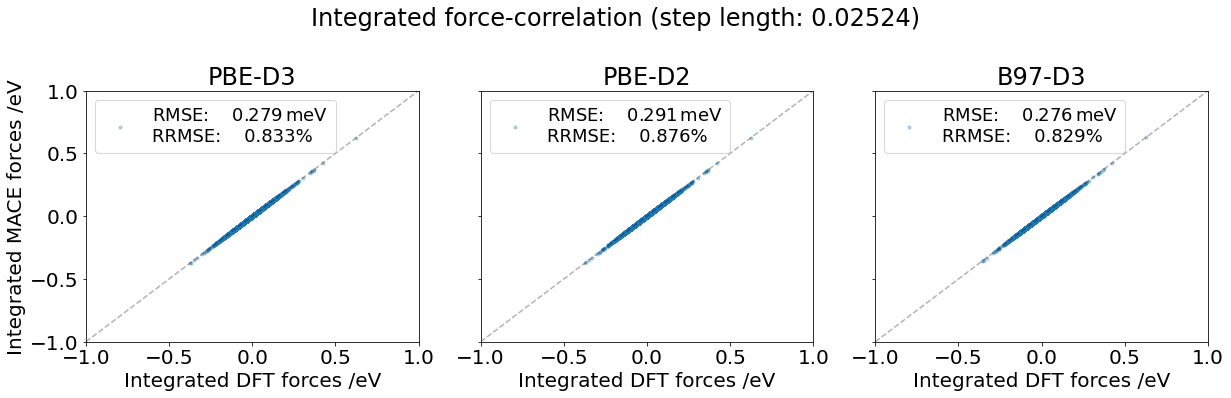

In [426]:
step_length = 0.02524

fig, axs = plt.subplots(1,len(tags), figsize=(7*scale, 2.3*scale), sharex=True, sharey=True)
for i, k in enumerate(step_xyz):
    tag = tags[i]
    atoms = xyz[k]
    data_set, labels, seed, dset_sample = tag.split('/')
    
    # Obtain forces and errors
    ## reference
    ref_forces = [a.arrays['forces']*step_length for a in atoms if 'forces' in a.arrays.keys()]
    ref_forces = np.concatenate(ref_forces).flatten()

    ## mace
    mace_forces = [a.arrays['MACE_forces']*step_length for a in atoms if 'forces' in a.arrays.keys()]
    mace_forces = np.concatenate(mace_forces).flatten()
    rmse, rrmse = RMSE(ref_forces, mace_forces)

    # Plot correlations
    axs[i].set_title(label_map[labels])
    axs[i].plot(ref_forces, mace_forces, '.', label=f'RMSE:    {rmse*1e3:.3f}$\\,$meV\nRRMSE:    {rrmse*100:.3f}%', alpha=0.3, rasterized=True)
    axs[i].legend(loc='upper left', numpoints=1, fontsize=fsize-2)

    # Plot settings
    axs[i].plot([0, 1], [0, 1], 'k--', transform=axs[i].transAxes, alpha=0.3)
    axs[i].set_xlabel('Integrated DFT forces /eV')
    axs[i].set_xlim([-1,1])
    axs[i].set_ylim([-1,1])
    if i == 0: axs[i].set_ylabel('Integrated MACE forces /eV')

fig.suptitle(f'Integrated force-correlation (step length: {step_length:.5f})')    
plt.tight_layout()

## Structural properties

The cell below takes a long while to run...

In [215]:
rdfs, number_densities = get_rdfs(path, tags)

with open('./part1_rdfs.pkl', 'wb') as f:
    pickle.dump(rdfs, f)

with open('./part1_rhos.pkl', 'wb') as f:
    pickle.dump(number_densities, f)

IBM23_PBED3 DSET1 SEED1
../publication/zenodo/IBM23/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/zenodo/IBM23/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/zenodo/IBM23/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/zenodo/IBM23/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz
IBM23_PBED2 DSET1 SEED1
../publication/zenodo/IBM23/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/zenodo/IBM23/PBED2/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/zenodo/IBM23/PBED2/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/zenodo/IBM23/PBED2/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz
IBM23_B97D3 DSET1 SEED1
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz
../publication/zenodo/IBM23/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


In [219]:
with open('./part1_rdfs.pkl', 'rb') as f:
    rdfs = pickle.load(f)

with open('./part1_rhos.pkl', 'rb') as f:
    number_densities = pickle.load(f)

Average (std.) first shell coordinations:
B97-D3: R: 7.56 (0.42), CN: 10.42 (0.34)
PBE-D2: R: 7.45 (0.42), CN: 9.84 (0.36)
PBE-D3: R: 7.64 (0.40), CN: 9.74 (0.39)



,Labels,Composition,Rmin,CN
0,PBE-D3,EMC,8.09,9.44
1,PBE-D3,EC:EMC (3:7),7.86,9.85
2,PBE-D3,EC:EMC (7:3),7.43,9.45
3,PBE-D3,EC,7.20,10.25
4,PBE-D2,EMC,7.98,9.93
5,PBE-D2,EC:EMC (3:7),7.54,9.36
6,PBE-D2,EC:EMC (7:3),7.32,9.82
7,PBE-D2,EC,6.98,10.22
8,B97-D3,EMC,8.09,10.87
9,B97-D3,EC:EMC (3:7),7.64,10.08


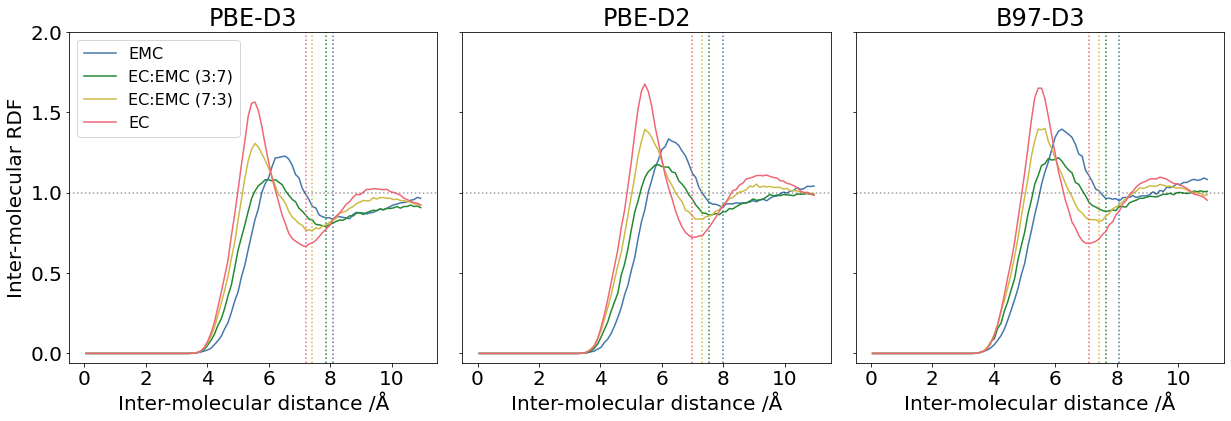

In [322]:
rstart = 6
id_width = 20
radii = []


fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_title(model_map[model])
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    for comp, (g, r) in comps.items():
                        id0 = np.where(r>rstart)[0][0]                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color=cset.black, alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, labels = model.split('_')
                        radii.append([label_map[labels], comp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()


radii_df = pd.DataFrame(radii, columns=['Labels', 'Composition', 'Rmin', 'CN'])
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Labels'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')
print()
radii_df.round(decimals=2)